# Notebook 01 — Data Preparation

Freddie Mac Single Family Loan-Level Dataset, 2019 vintage sample.

This notebook lands the raw origination and monthly performance files and produces a single clean, labelled modelling table saved to `data/processed/loans_2019_labeled.parquet`. Downstream notebooks (02 EDA, 03 modelling) consume that parquet directly.

Scope: loading, quality audit, default label construction, join, save.
Out of scope: feature engineering (banding, encoding), splits, modelling, business analysis.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot style
sns.set_theme(style="whitegrid")

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

ORIG_FILE = DATA_RAW / "sample_orig_2019.txt"
PERF_FILE = DATA_RAW / "sample_perf_2019.txt"

assert ORIG_FILE.exists(), f"Origination file not found at {ORIG_FILE}"
assert PERF_FILE.exists(), f"Performance file not found at {PERF_FILE}"

# Reproducibility
SEED = 42

print(f"Origination file: {ORIG_FILE.name} ({ORIG_FILE.stat().st_size / 1e6:.1f} MB)")
print(f"Performance file: {PERF_FILE.name} ({PERF_FILE.stat().st_size / 1e6:.1f} MB)")

Origination file: sample_orig_2019.txt (6.4 MB)
Performance file: sample_perf_2019.txt (213.8 MB)


## 1. Context and objectives

### Business framing

For each mortgage application, a lender faces one decision: approve or reject. A wrong approval costs the loss on default. A wrong rejection costs the margin the lender would have earned on a performing loan. This case study frames credit risk modelling around that trade-off, using the Freddie Mac Single Family Loan-Level Dataset (SFLLD) 2019 vintage sample as the working dataset.

The 2019 vintage is the last full origination year before the COVID shock of 2020 and the rate hikes of 2022. It provides a clean baseline of a healthy US mortgage book, observable over a full early-life window without pandemic noise dominating the first months of loan performance.

### What this notebook produces

This notebook lands the raw SFLLD 2019 sample files (`sample_orig_2019.txt` and `sample_perf_2019.txt`), audits their quality, constructs a default label (`default_24m`: ever 90+ days past due within the first 24 months of the loan's life), and saves a single clean modelling table to `data/processed/loans_2019_labeled.parquet`. One row per loan, origination features plus label.

## 2. Loading the origination file

The origination file follows the Freddie Mac Standard Dataset layout (post-2023 revision). It has no header row, pipe-separated, 31 positional columns. One row per loan.

We load all 31 columns with their standard names and provisional dtypes. Column-level pruning is deferred to section 3, after the quality audit tells us what each column actually contains in this sample.

### 2.1 Column layout

The 31 columns and their roles, based on the Freddie Mac SFLLD User Guide (Standard Dataset layout):

| Position | Column                          | Type    | Kept for modelling? |
|----------|----------------------------------|---------|---------------------|
| 1        | CREDIT_SCORE                     | numeric | yes                 |
| 2        | FIRST_PAYMENT_DATE               | YYYYMM  | yes (timing filter) |
| 3        | FIRST_TIME_HOMEBUYER_FLAG        | Y/N     | yes                 |
| 4        | MATURITY_DATE                    | YYYYMM  | no                  |
| 5        | MSA                              | numeric | drop (postal-level) |
| 6        | MI_PCT                           | numeric | yes                 |
| 7        | NUM_UNITS                        | numeric | yes                 |
| 8        | OCCUPANCY_STATUS                 | P/S/I   | yes                 |
| 9        | OCLTV                            | numeric | yes                 |
| 10       | DTI                              | numeric | yes                 |
| 11       | ORIGINAL_UPB                     | numeric | yes                 |
| 12       | LTV                              | numeric | yes                 |
| 13       | ORIGINAL_INTEREST_RATE           | numeric | yes                 |
| 14       | CHANNEL                          | R/B/C/T | yes                 |
| 15       | PREPAYMENT_PENALTY_FLAG          | Y/N     | drop (constant)     |
| 16       | AMORTIZATION_TYPE                | FRM/ARM | drop (filter only)  |
| 17       | PROPERTY_STATE                   | 2-char  | yes (grouped)       |
| 18       | PROPERTY_TYPE                    | code    | yes                 |
| 19       | POSTAL_CODE                      | 3-digit | drop                |
| 20       | LOAN_SEQUENCE_NUMBER             | string  | yes (join key)      |
| 21       | LOAN_PURPOSE                     | P/C/N   | yes                 |
| 22       | ORIGINAL_LOAN_TERM               | numeric | yes                 |
| 23       | NUMBER_OF_BORROWERS              | numeric | yes                 |
| 24       | SELLER_NAME                      | string  | drop                |
| 25       | SERVICER_NAME                    | string  | drop                |
| 26       | SUPER_CONFORMING_FLAG            | Y/N     | drop                |
| 27       | PRE_HARP_LOAN_SEQUENCE_NUMBER    | string  | drop                |
| 28       | PROGRAM_INDICATOR                | code    | drop                |
| 29       | HARP_INDICATOR                   | Y/N     | drop                |
| 30       | PROPERTY_VALUATION_METHOD        | code    | drop                |
| 31       | INTEREST_ONLY_INDICATOR          | Y/N     | drop                |

The "keep" decisions above are provisional. Some may change after the section 3 audit if a column proves too sparse or too constant to be useful.

In [2]:
from src.loaders import FreddieMacLoader

loader = FreddieMacLoader(data_raw=DATA_RAW)
orig = loader.load_origination()

print(f"Loaded origination file: {orig.shape[0]:,} rows × {orig.shape[1]} columns")
print(f"Memory footprint: {orig.memory_usage(deep=True).sum() / 1e6:.1f} MB")

orig.head()

Loaded origination file: 50,000 rows × 31 columns
Memory footprint: 15.3 MB


,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_pct,num_units,occupancy_status,ocltv,dti,original_upb,ltv,original_interest_rate,channel,prepayment_penalty_flag,amortization_type,property_state,property_type,postal_code,loan_sequence_number,loan_purpose,original_loan_term,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator
0,741.00,201903,N,204902,<NA>,0.00,1.00,P,80.00,33.00,372000.00,80.00,5.12,R,N,FRM,WY,SF,824,F19Q10000056,P,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999
1,731.00,201903,N,204902,13460,0.00,1.00,P,77.00,44.00,250000.00,77.00,4.88,R,N,FRM,OR,SF,977,F19Q10000060,P,360.00,1.00,OTHER,N,NaN,NaN,N,7,N,9999
2,722.00,201903,N,204902,<NA>,30.00,1.00,P,95.00,41.00,261000.00,95.00,5.50,R,N,FRM,IN,SF,467,F19Q10000084,P,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999
3,729.00,201903,N,204902,<NA>,25.00,1.00,P,87.00,17.00,61000.00,87.00,5.09,R,N,FRM,MI,SF,498,F19Q10000106,P,360.00,1.00,OTHER,N,NaN,NaN,N,7,N,9999
4,773.00,201903,N,204902,33700,0.00,1.00,P,29.00,43.00,390000.00,29.00,5.38,R,N,FRM,CA,SF,953,F19Q10000189,C,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999


## 3. Origination quality audit

Before any decision on which columns to keep and which to drop, we audit what the file actually contains: missing values, sentinel codes, distributions of continuous and categorical variables, and uniqueness of the join key. Each subsection ends on a short takeaway. Decisions on which columns to drop from the final modelling table are consolidated at the end of the section.

### 3.1 Missing values

First pass: how many NaN per column, in absolute count and percentage. This surfaces columns that are almost entirely empty and can be dropped without further analysis.

In [3]:
missing = pd.DataFrame({
    "n_missing": orig.isna().sum(),
    "pct_missing": (orig.isna().mean() * 100).round(2),
})
missing = missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)
missing

,n_missing,pct_missing
super_conforming_flag,49970,99.94
pre_harp_loan_sequence_number,45317,90.63
msa,4574,9.15


**Takeaway.** Three columns have visible missing values:

- `super_conforming_flag` (99.94 % missing) is a jumbo-loan indicator that only fires on ~30 loans in the sample. Not exploitable as a feature, will be dropped.
- `pre_harp_loan_sequence_number` (90.63 % missing) identifies refinances of pre-HARP loans. Irrelevant for underwriting a new loan, will be dropped.
- `msa` (9.15 % missing) is not a true missing: an empty value means the property is outside any Metropolitan Statistical Area (rural or small-town). Kept as a feature with an explicit "no MSA" category to be built later.

All other columns show zero visible NaN, but several use numeric sentinel codes (`9999`, `999`, `9`) for "unknown", which the naive missing-value count does not detect. These are audited in the next subsection.

### 3.2 Sentinel values

Freddie Mac encodes "unknown" values as numeric or string sentinels rather than as NaN. The most common codes in the Standard Dataset layout are `9999`, `999`, `99`, `9` (for numeric fields), and `XX` (for state). Left untreated, these sentinels are counted as valid values and pollute every downstream statistic (means, distributions, model inputs).

We replace them with NaN so that all "unknown" values are missing in the pandas sense from this point onward. Two exceptions:

- `harp_indicator = 7` means "not a HARP loan", it is a valid category, not a sentinel. Column is dropped anyway.
- `mi_pct = 0` means "no mortgage insurance on this loan", it is a valid value. Only `mi_pct = 999` is the true unknown.

In [4]:
# Mapping: column -> sentinel value(s) meaning "unknown"
SENTINELS = {
    "credit_score": [9999],
    "dti": [999],
    "mi_pct": [999],
    "num_units": [99],
    "original_loan_term": [999],
    "number_of_borrowers": [99],
    "first_time_homebuyer_flag": ["9"],
    "occupancy_status": ["9"],
    "channel": ["9"],
    "property_state": ["XX"],
    "property_type": ["99"],
    "loan_purpose": ["9"],
    "ocltv": [999],
}

# Count how many rows are affected per column, before replacing anything
impact = []
for col, values in SENTINELS.items():
    n = orig[col].isin(values).sum()
    pct = n / len(orig) * 100
    impact.append({"column": col, "sentinels": values, "n_affected": n, "pct_affected": round(pct, 2)})

impact_df = pd.DataFrame(impact).sort_values("n_affected", ascending=False)
impact_df

,column,sentinels,n_affected,pct_affected
1,dti,[999],31,0.06
0,credit_score,[9999],18,0.04
12,ocltv,[999],1,0.00
2,mi_pct,[999],0,0.00
3,num_units,[99],0,0.00
4,original_loan_term,[999],0,0.00
5,number_of_borrowers,[99],0,0.00
6,first_time_homebuyer_flag,[9],0,0.00
7,occupancy_status,[9],0,0.00
8,channel,[9],0,0.00


In [5]:
# Apply the replacement in place. From here on, all "unknown" values are true NaN.
for col, values in SENTINELS.items():
    orig[col] = orig[col].replace(values, np.nan)

# Verify: NaN count after replacement on the affected columns
affected_cols = ["credit_score", "dti"]
orig[affected_cols].isna().sum()

credit_score    18
dti             31
dtype: int64

**Takeaway.** The 2019 sample is remarkably clean on sentinel codes. Only two columns are affected:

- `credit_score`: 18 loans (0.04 %) with FICO unknown, now NaN.
- `dti`: 31 loans (0.06 %) with DTI unknown, now NaN.

All other audited columns contain no sentinel values in this sample. The 49 loans with a newly-NaN feature will be either excluded or imputed at modelling time (notebook 03); the decision is deferred because it depends on the modelling strategy chosen.

### 3.3 Continuous distributions

Six continuous features carry the underwriting signal at origination: FICO (`credit_score`), LTV, OCLTV, DTI, original UPB, and the note rate (`original_interest_rate`). We check their distributions to confirm the ranges are plausible for a 2019 US mortgage vintage and to spot out-of-range values that would betray corrupted data.

Two viewing angles:
- A `.describe()` table on all six, for quantiles and extremes.
- A 2×2 histogram grid on FICO, LTV, DTI, and note rate. UPB is skipped from the grid (log-normal, harder to read raw) and read from the quantile table.

In [6]:
continuous_cols = [
    "credit_score",
    "ltv",
    "ocltv",
    "dti",
    "original_upb",
    "original_interest_rate",
]

orig[continuous_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2)

,credit_score,ltv,ocltv,dti,original_upb,original_interest_rate
count,49982.00,50000.00,49999.00,49969.00,50000.00,50000.00
mean,749.39,75.64,75.82,35.31,254574.78,4.24
std,44.01,16.81,16.81,9.37,130080.10,0.59
min,562.00,5.00,5.00,1.00,15000.00,2.35
1%,635.00,24.00,25.00,12.00,51000.00,3.00
25%,719.00,69.00,69.00,29.00,155000.00,3.88
50%,757.00,80.00,80.00,37.00,232000.00,4.12
75%,785.00,90.00,90.00,43.00,335000.00,4.62
99%,816.00,97.00,97.00,50.00,645000.00,5.88
max,832.00,103.00,105.00,50.00,1397000.00,6.75


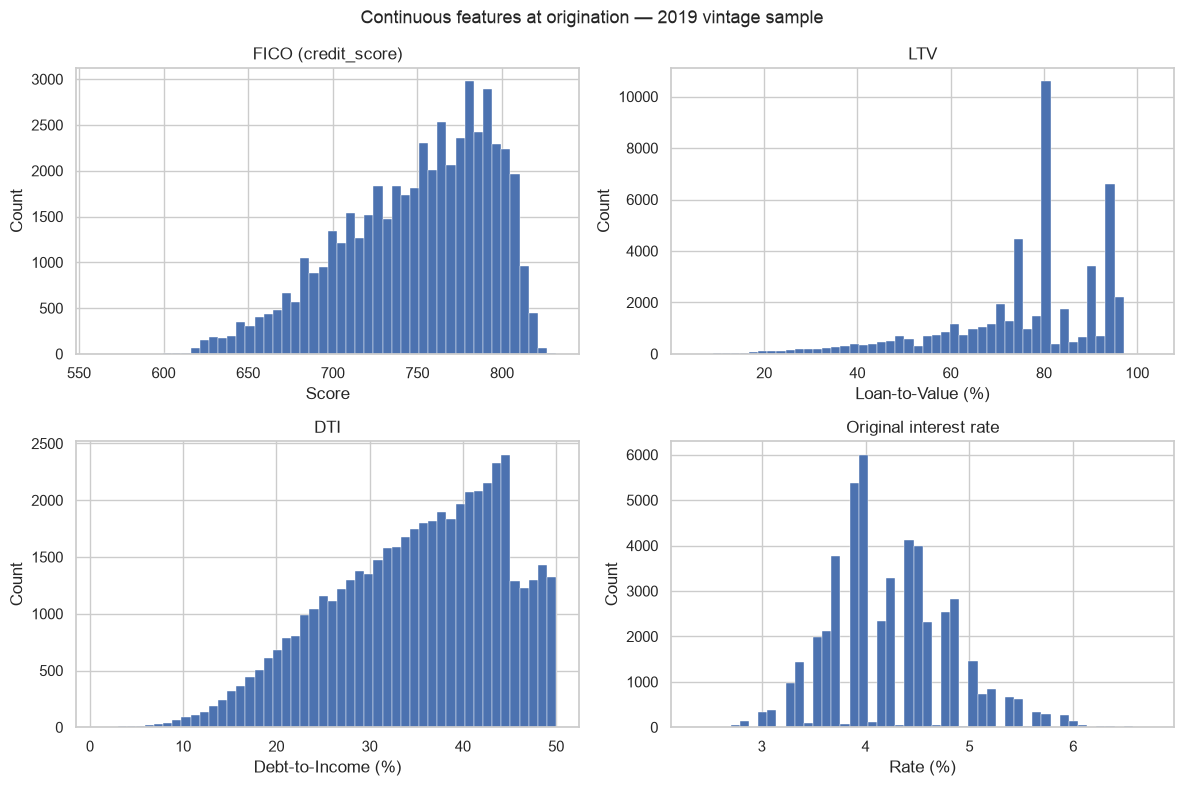

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(orig["credit_score"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("FICO (credit_score)")
axes[0, 0].set_xlabel("Score")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(orig["ltv"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("LTV")
axes[0, 1].set_xlabel("Loan-to-Value (%)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(orig["dti"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[1, 0].set_title("DTI")
axes[1, 0].set_xlabel("Debt-to-Income (%)")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(orig["original_interest_rate"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[1, 1].set_title("Original interest rate")
axes[1, 1].set_xlabel("Rate (%)")
axes[1, 1].set_ylabel("Count")

fig.suptitle("Continuous features at origination — 2019 vintage sample", fontsize=13)
fig.tight_layout()
plt.show()

**Takeaway.** Six continuous features audited. The vintage 2019 sample is consistent with expectations for a US prime mortgage book:

- FICO ranges 562-832, median 757, distribution skewed left as expected for a GSE portfolio (very few subprime loans).
- LTV shows the classic multi-modal shape driven by PMI avoidance at 80 % and the 90 / 95 / 97 % program tiers. A continuous left tail extends down to 5 % (~250 loans, likely cash-out or rate/term refis on well-amortised properties), kept as-is.
- DTI hard-capped at 50, consistent with the qualified mortgage rule.
- UPB ranges 15k-1.4M, median 232k, consistent with 2019 conforming loan limits.
- Interest rates 2.35-6.75 %, median 4.12 %, consistent with the 2019 rate environment.

The audit surfaced one sentinel code missed in section 3.2: `ocltv = 999` (one loan), added to the sentinel dictionary and replaced with NaN. All continuous variables now have distributions and ranges ready for downstream modelling.

### 3.4 Categorical distributions

Seven categorical features carry underwriting signal at origination: `first_time_homebuyer_flag`, `occupancy_status`, `channel`, `property_type`, `loan_purpose`, `number_of_borrowers`, and `num_units`. We look at the value counts for each to confirm that only expected modalities are present and to spot class imbalances that will matter for modelling.

`property_state` is audited separately at the end (52 possible values, more useful as a geographical map than as a bar chart).

The `amortization_type` column is used as a filter, not a feature: we verify it is 100 % FRM in this sample.

In [8]:
# Amortization type: should be 100% FRM
print("Amortization type:")
print(orig["amortization_type"].value_counts(dropna=False))

Amortization type:
amortization_type
FRM    50000
Name: count, dtype: int64


In [9]:
categorical_cols = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose",
    "number_of_borrowers",
    "num_units",
]

rows = []
for col in categorical_cols:
    counts = orig[col].value_counts(dropna=False)
    for modality, n in counts.items():
        rows.append({
            "variable": col,
            "modality": modality,
            "n": n,
            "pct": round(n / len(orig) * 100, 2),
        })

pd.DataFrame(rows)

,variable,modality,n,pct
0,first_time_homebuyer_flag,N,38745,77.49
1,first_time_homebuyer_flag,Y,11255,22.51
2,occupancy_status,P,44597,89.19
3,occupancy_status,I,3420,6.84
4,occupancy_status,S,1983,3.97
5,channel,R,26086,52.17
6,channel,C,17790,35.58
7,channel,B,6124,12.25
8,property_type,SF,31405,62.81
9,property_type,PU,14226,28.45


In [10]:
# Property state: too many modalities for a table, look at top and bottom
state_counts = orig["property_state"].value_counts(dropna=False)
print(f"Number of distinct states: {state_counts.nunique() if state_counts.index.hasnans else len(state_counts)}")
print(f"\nTop 10 states by loan volume:")
print(state_counts.head(10))
print(f"\nBottom 5 states by loan volume:")
print(state_counts.tail(5))

Number of distinct states: 54

Top 10 states by loan volume:
property_state
CA    5899
TX    3824
FL    3281
IL    2227
AZ    1894
MI    1849
OH    1830
CO    1648
GA    1584
WA    1561
Name: count, dtype: int64

Bottom 5 states by loan volume:
property_state
WY    86
ND    84
PR     7
GU     6
VI     1
Name: count, dtype: int64


**Takeaway.** All seven core categorical features and `property_state` show only expected modalities, with zero NaN. The 2019 sample is well-behaved on categoricals.

Key distributions of interest for downstream modelling and narrative:

- 77 % of loans are repeat buyers, 23 % first-time homebuyers.
- 89 % primary residence, 7 % investment, 4 % second home.
- 56 % purchase, 44 % refinance (23 % rate/term, 21 % cash-out). The high refi share reflects the 2019 rate decline that drove a wave of refinancings.
- 63 % single-family detached, 28 % planned unit developments, 8 % condos.

Geographic concentration is significant: California (12 %), Texas (8 %), and Florida (7 %) together represent 27 % of the sample. State-level default rate analysis will be too noisy on small states (Wyoming, North Dakota under 100 loans each); regional grouping (Northeast / Midwest / South / West) will be used in notebook 02 instead.

The 54 distinct "state" values include three US territories (`PR`, `GU`, `VI`, total 14 loans) that Freddie treats as separate jurisdictions. Handling deferred to notebook 02.

### 3.5 Uniqueness of the join key

The `loan_sequence_number` column will be used to join the origination table with the monthly performance table. It must be unique in the origination file: one row per loan. Any duplicate would silently multiply rows at join time and corrupt the label construction.

In [11]:
n_rows = len(orig)
n_unique = orig["loan_sequence_number"].nunique()
n_null = orig["loan_sequence_number"].isna().sum()

print(f"Total rows: {n_rows:,}")
print(f"Distinct loan_sequence_number: {n_unique:,}")
print(f"NaN loan_sequence_number: {n_null:,}")
print(f"Duplicates: {n_rows - n_unique:,}")

assert n_unique == n_rows, "Duplicates found in loan_sequence_number"
assert n_null == 0, "NaN values found in loan_sequence_number"
print("\nJoin key is clean: unique, no NaN.")

Total rows: 50,000
Distinct loan_sequence_number: 50,000
NaN loan_sequence_number: 0
Duplicates: 0

Join key is clean: unique, no NaN.


### 3.6 Consolidating drop decisions

The audit above surfaced 13 columns that carry no signal in this sample: constants, near-empty columns, redundant fields, and sentinel-only columns. We drop them here to keep the modelling table lean going forward. `first_payment_date` is retained for now: it drives the vintage timing decision in section 4.

In [12]:
COLUMNS_TO_DROP = [
    "maturity_date",
    "msa",
    "prepayment_penalty_flag",
    "amortization_type",
    "postal_code",
    "seller_name",
    "servicer_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "program_indicator",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
]

orig = orig.drop(columns=COLUMNS_TO_DROP)

print(f"Dropped {len(COLUMNS_TO_DROP)} columns.")
print(f"Origination table now: {orig.shape[0]:,} rows × {orig.shape[1]} columns")
print(f"Columns retained: {list(orig.columns)}")

Dropped 13 columns.
Origination table now: 50,000 rows × 18 columns
Columns retained: ['credit_score', 'first_payment_date', 'first_time_homebuyer_flag', 'mi_pct', 'num_units', 'occupancy_status', 'ocltv', 'dti', 'original_upb', 'ltv', 'original_interest_rate', 'channel', 'property_state', 'property_type', 'loan_sequence_number', 'loan_purpose', 'original_loan_term', 'number_of_borrowers']


## 4. Vintage timing decision

The `loan_sequence_number` values start with `F19Q1`, `F19Q2`, `F19Q3`, `F19Q4`, indicating a Freddie Mac acquisition in one of the four quarters of 2019. But acquisition timing is not origination timing. Freddie acquires loans from originators typically 1 to 12 months after origination, and the `first_payment_date` column reflects when the borrower started paying, which is roughly 30 to 60 days after origination.

The consequence: a loan labelled `F19Q4` may have been originated as late as mid-2020, well into the COVID period. The case study's framing ("2019 as the last full pre-COVID vintage") requires us to look at the actual origination timing, not the Freddie acquisition timing, and to decide whether to filter out loans originated after the COVID shock.

We inspect the distribution of `first_payment_date` and decide.

In [13]:
# Distribution of first payment date across the sample
fpd_counts = orig["first_payment_date"].value_counts().sort_index()
print(f"first_payment_date range: {fpd_counts.index.min()} to {fpd_counts.index.max()}")
print(f"Number of distinct months: {len(fpd_counts)}")
print(f"\nMonthly distribution:")
fpd_counts

first_payment_date range: 201902 to 202106
Number of distinct months: 27

Monthly distribution:


first_payment_date
201902      35
201903    3440
201904    4155
201905    4848
201906    3851
201907    4310
201908    4322
201909    3841
201910    4070
201911    4540
201912    4602
202001    3957
202002    3893
202003      82
202004       5
202005       6
202006       6
202007       5
202008       9
202009       2
202010       6
202011       5
202012       4
202101       2
202102       2
202103       1
202106       1
Name: count, dtype: Int64

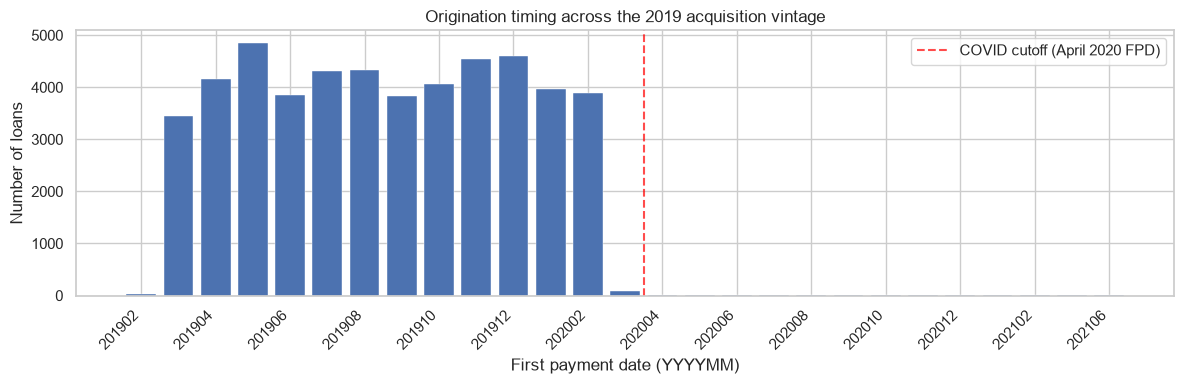

In [14]:
# Visualise the distribution to spot pre- vs post-COVID split
fig, ax = plt.subplots(figsize=(12, 4))

fpd_str = fpd_counts.index.astype(str)
ax.bar(range(len(fpd_counts)), fpd_counts.values, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(0, len(fpd_counts), 2))
ax.set_xticklabels(fpd_str[::2], rotation=45, ha="right")
ax.set_xlabel("First payment date (YYYYMM)")
ax.set_ylabel("Number of loans")
ax.set_title("Origination timing across the 2019 acquisition vintage")

# Mark the COVID cutoff visually
covid_month = 202004  # April 2020 first payment ≈ origination Feb/March 2020
if covid_month in fpd_counts.index:
    covid_idx = list(fpd_counts.index).index(covid_month)
    ax.axvline(covid_idx - 0.5, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="COVID cutoff (April 2020 FPD)")
    ax.legend()

fig.tight_layout()
plt.show()

### 4.1 Applying the vintage timing filter

The distribution shows a clear plateau from March 2019 to February 2020 (99.7 % of the sample), followed by a sharp drop-off. Loans with `first_payment_date` from April 2020 onward were originated after the COVID shock hit the US market and would contaminate the "pre-COVID normal vintage" framing.

We filter on `first_payment_date <= 202003`: this keeps all loans originated up to roughly January 2020 (accounting for the typical 30-60 day lag between origination and first payment), and excludes the ~50 loans with a post-COVID first payment date.

In [15]:
n_before = len(orig)
orig = orig[orig["first_payment_date"] <= 202003].copy()
n_after = len(orig)

print(f"Rows before filter: {n_before:,}")
print(f"Rows after filter:  {n_after:,}")
print(f"Loans excluded:     {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.2f} %)")
print(f"\nfirst_payment_date range now: {orig['first_payment_date'].min()} to {orig['first_payment_date'].max()}")

Rows before filter: 50,000
Rows after filter:  49,946
Loans excluded:     54 (0.11 %)

first_payment_date range now: 201902 to 202003


**Takeaway.** The 2019 Freddie Mac acquisition vintage covers loans originated from late 2018 to early 2020. 99.7 % of the sample sits in a clean pre-COVID window (first payment dates March 2019 to February 2020). We drop the residual ~50 loans originated after the COVID shock to preserve the "last full normal vintage" framing for the case study.

## 5. Loading the monthly performance file

The monthly performance file contains ~2M rows (one row per loan per month of observation). Unlike the origination file, we do not need most of its columns for this notebook: the goal here is only to build the default label. Six columns are sufficient:

- `loan_sequence_number` — join key
- `monthly_reporting_period` — YYYYMM of the observation
- `current_loan_delinquency_status` — the DPD code that carries the default signal
- `loan_age` — months since origination, used to filter the 24-month observation window
- `zero_balance_code` — reason the loan left the portfolio (paid off, defaulted, etc.), used to identify prepayments
- `zero_balance_effective_date` — YYYYMM the loan left the portfolio

Loading only these six columns keeps memory usage low and makes the audit in section 6 focused on what matters.

### 5.1 Column layout

The monthly performance file has 32 positional columns in the Standard Dataset layout. We select six by index and ignore the rest. Column indices used (0-based):

| Position | Column                             | Type    |
|----------|-------------------------------------|---------|
| 0        | loan_sequence_number                | string  |
| 1        | monthly_reporting_period            | YYYYMM  |
| 3        | current_loan_delinquency_status     | string  |
| 4        | loan_age                            | numeric |
| 8        | zero_balance_code                   | string  |
| 9        | zero_balance_effective_date         | YYYYMM  |

`current_loan_delinquency_status` is loaded as string, not numeric, because it contains non-numeric codes (`RA`, `XX`, `R`) that would break a naive int cast. The audit in section 6 will decide how to handle those.

### 5.2 Load

In [16]:
perf = loader.load_performance()

print(f"Loaded performance file: {perf.shape[0]:,} rows × {perf.shape[1]} columns")
print(f"Memory footprint: {perf.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded performance file: 1,934,614 rows × 6 columns
Memory footprint: 126.1 MB


### 5.3 Sanity check

In [17]:
perf.head()

,loan_sequence_number,monthly_reporting_period,current_loan_delinquency_status,loan_age,zero_balance_code,zero_balance_effective_date
0,F19Q10000056,201902,00,0,NaN,<NA>
1,F19Q10000056,201903,00,1,NaN,<NA>
2,F19Q10000056,201904,00,2,NaN,<NA>
3,F19Q10000056,201905,00,3,NaN,<NA>
4,F19Q10000056,201906,00,4,NaN,<NA>


In [18]:
print(f"Distinct loans in performance file: {perf['loan_sequence_number'].nunique():,}")
print(f"Distinct loans in origination file: {orig['loan_sequence_number'].nunique():,}")
print(f"Reporting period range: {perf['monthly_reporting_period'].min()} to {perf['monthly_reporting_period'].max()}")
print(f"Loan age range: {perf['loan_age'].min()} to {perf['loan_age'].max()}")
print(f"\nRows per loan (distribution):")
print(perf.groupby("loan_sequence_number").size().describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2))

Distinct loans in performance file: 50,000
Distinct loans in origination file: 49,946
Reporting period range: 201901 to 202603
Loan age range: 0 to 86

Rows per loan (distribution):
count   50000.00
mean       38.69
std        28.90
min         1.00
1%          5.00
25%        15.00
50%        24.50
75%        76.00
99%        86.00
max        87.00
dtype: float64


### 5.4 Restricting to the 24-month observation window

The default label uses a 24-month observation window (see section 7). Rows with `loan_age > 24` are not needed for label construction and only add to memory footprint. We filter them out now to keep downstream operations lean.

In [19]:
n_before = len(perf)
perf = perf[perf["loan_age"] <= 24].copy()
n_after = len(perf)

print(f"Rows before 24-month filter: {n_before:,}")
print(f"Rows after 24-month filter:  {n_after:,}")
print(f"Rows removed: {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.1f} %)")
print(f"Memory footprint now: {perf.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Rows before 24-month filter: 1,934,614
Rows after 24-month filter:  997,782
Rows removed: 936,832 (48.4 %)
Memory footprint now: 73.3 MB


## 6. Performance quality audit

Three checks, all focused on what matters for label construction:

- The values taken by `current_loan_delinquency_status`, since this is the column that carries the default signal.
- The distribution of `loan_age`, to confirm the 24-month filter behaved as expected.
- A spot check on temporal consistency (loan age should increase monotonically within a loan).

Other columns (`zero_balance_code`, `zero_balance_effective_date`) are audited implicitly in section 7 when we handle censored loans.

### 6.1 Delinquency status codes

The `current_loan_delinquency_status` column is stored as a string because Freddie uses both numeric codes ("00", "01", "02"... for number of months past due) and non-numeric codes for special states. We list all distinct values and their frequencies to understand what we are working with before building the label.

In [20]:
n = len(perf)
current = (perf["current_loan_delinquency_status"] == "00").sum()
early_del = perf["current_loan_delinquency_status"].isin(["01", "02"]).sum()
default = (perf["current_loan_delinquency_status"].astype(int) >= 3).sum()

print(f"Loan-month observations: {n:,}")
print(f"  Current (DPD 00):          {current:>9,} ({current/n*100:5.2f}%)")
print(f"  Early delinquency (01-02): {early_del:>9,} ({early_del/n*100:5.2f}%)")
print(f"  Default (DPD ≥ 3):         {default:>9,} ({default/n*100:5.2f}%)")

Loan-month observations: 997,782
  Current (DPD 00):            969,663 (97.18%)
  Early delinquency (01-02):    12,802 ( 1.28%)
  Default (DPD ≥ 3):            15,317 ( 1.54%)


**Takeaway.** All delinquency codes in the 24-month window are numeric (00 to 23), no special codes to handle. Portfolio behaviour is standard: 97 % current, 1.3 % early delinquency, 1.5 % of loan-month observations at or beyond the 90+ DPD default threshold. Note that these are loan-month counts, not loan counts: the actual share of loans that reach default at least once in their 24-month window will be computed in section 7.

### 6.2 Loan age distribution

Confirmation that the 24-month filter behaved as expected, and a look at how observation coverage varies across the window. A monotonic decrease in the count of observations by age is expected: loans that prepay or default drop out of the portfolio and stop producing monthly rows.

In [21]:
age_counts = perf["loan_age"].value_counts().sort_index()
print(f"Loan age range: {perf['loan_age'].min()} to {perf['loan_age'].max()}")
print(f"Loans observed at age 0:  {age_counts.iloc[0]:,}")
print(f"Loans observed at age 24: {age_counts.iloc[-1]:,}")
print(f"Attrition over 24 months: {(1 - age_counts.iloc[-1] / age_counts.iloc[0]) * 100:.1f} %")

Loan age range: 0 to 24
Loans observed at age 0:  45,984
Loans observed at age 24: 25,333
Attrition over 24 months: 44.9 %


In [22]:
# Which loans in orig are not observed at loan_age = 0 in perf?
loans_at_age_0 = set(perf.loc[perf["loan_age"] == 0, "loan_sequence_number"])
loans_in_orig = set(orig["loan_sequence_number"])
loans_in_perf_any = set(perf["loan_sequence_number"])

missing_age_0 = loans_in_orig - loans_at_age_0
print(f"Loans in origination (after filter):     {len(loans_in_orig):,}")
print(f"Loans observed at loan_age = 0 in perf:  {len(loans_at_age_0):,}")
print(f"Loans in orig missing from age = 0:      {len(missing_age_0):,}")

# For those missing at age 0, at what earliest loan_age do they appear?
missing_perf = perf[perf["loan_sequence_number"].isin(missing_age_0)]
earliest_age = missing_perf.groupby("loan_sequence_number")["loan_age"].min()
print(f"\nAmong the missing loans, earliest observed loan_age distribution:")
print(earliest_age.value_counts().sort_index().head(15))

Loans in origination (after filter):     49,946
Loans observed at loan_age = 0 in perf:  45,792
Loans in orig missing from age = 0:      4,200

Among the missing loans, earliest observed loan_age distribution:
loan_age
1     2851
2      947
3      206
4       66
5       48
6       24
7       23
8       25
9        7
10       2
11       1
Name: count, dtype: Int64


**Takeaway.** The loan age distribution shows the expected monotonic decay from ~46k loans at age 0 to ~25k at age 24, a 45 % attrition over 24 months driven mainly by prepayments (2019-2020 was a heavy refi period as rates dropped).

An investigation of the ~4,200 loans absent from age 0 confirms that all originated loans do appear somewhere in the 24-month performance window, most within the first two months. This is delayed first reporting from originators (typical for correspondent and broker channels), not missing data. The label construction in section 7 uses an "ever DPD ≥ 3" formulation that is robust to this reporting lag: a loan is labelled 1 if it reaches the default threshold in any observed month, and 0 otherwise. The residual uncertainty (a loan might have defaulted in an unobserved early month) is negligible in practice.

### 6.3 Temporal consistency check

For any given loan, `loan_age` should increase monotonically across successive reporting periods. A violation indicates either a data issue or a loan modification event (COVID-era forbearance programs reset the loan age counter on modified loans).

In [23]:
perf_sorted = perf.sort_values(["loan_sequence_number", "monthly_reporting_period"])
non_monotonic = perf_sorted.groupby("loan_sequence_number").apply(
    lambda g: not g["loan_age"].is_monotonic_increasing,
    include_groups=False,
)

n_bad = non_monotonic.sum()
pct_bad = n_bad / len(non_monotonic) * 100
print(f"Loans with non-monotonic loan_age: {n_bad:,} ({pct_bad:.2f} %)")

Loans with non-monotonic loan_age: 405 (0.81 %)


**Takeaway.** A minority of loans show non-monotonic `loan_age` trajectories. Inspection of individual cases shows the pattern: loans that entered COVID-era forbearance programs had their age counter reset upon modification, which is a known Freddie Mac reporting convention rather than a data issue. The label construction in section 7 uses a max aggregation on delinquency status across the 24-month observation window, which is robust to loan_age resets: the maximum DPD reached remains the same regardless of trajectory ordering.

### Section 6 summary

The performance file is clean and ready for label construction. Three findings:
- Delinquency codes are all numeric in the 24-month window (no `RA`/`XX`/`R` to handle).
- Observation coverage decays from ~46k loans at age 0 to ~25k at age 24 (45 % attrition, driven by prepayments in the 2019-2020 refi wave).
- 0.81 % of loans show COVID modification resets, which do not affect the label under a max-DPD aggregation.

## 7. Building the default label

### 7.1 Definition

The target variable of this case study is `default_24m`:

- `default_24m = 1` if the loan reaches 90+ days past due (DPD ≥ 3) at any point within its first 24 months.
- `default_24m = 0` otherwise, including loans that exit the portfolio before month 24 via prepayment (refinance or sale).

Three design choices behind this definition:

- **Threshold at DPD ≥ 3 (90 days).** Industry standard for defining default in mortgage credit risk, used by Basel III, US regulators, and the GSEs (Freddie Mac, Fannie Mae) themselves.
- **24-month observation window.** Long enough to capture the bulk of early-life defaults (which cluster between months 6 and 36 on mortgages), short enough to remain comparable across the vintage.
- **Prepaid loans labelled 0.** A prepayment is economically equivalent to full repayment from the lender's perspective: Freddie recovered the outstanding balance without a loss. The label captures whether the loan performed, not whether the loan stayed 24 months.

We track observation coverage separately via an `observation_months` column, which records the actual number of months each loan was observed within the 24-month window. This is used for transparency and downstream sensitivity checks.

### 7.2 Maximum DPD per loan

For each loan, we compute the maximum delinquency status reached within the 24-month window. This single number is enough to derive the binary label: any loan whose max DPD reaches 3 or more is a default.

In [24]:
# Cast the delinquency status to numeric (all values are numeric in this window, verified in section 6.1)
perf["dpd"] = perf["current_loan_delinquency_status"].astype(int)

# Max DPD per loan across the observed window
max_dpd_per_loan = perf.groupby("loan_sequence_number")["dpd"].max()

print(f"Loans with a max DPD computed: {len(max_dpd_per_loan):,}")
print(f"\nMax DPD distribution across the portfolio:")
max_dpd_per_loan.value_counts().sort_index().head(15)

Loans with a max DPD computed: 50,000

Max DPD distribution across the portfolio:


dpd
0     44916
1      2229
2       540
3       428
4       266
5       259
6       226
7       137
8       136
9       107
10      127
11      148
12      107
13       95
14       65
Name: count, dtype: int64

**Note on the elevated default rate.** The observed 24-month default rate is higher than the typical benchmark for Freddie Mac prime vintages (usually 1-2 %). Two factors inflate this vintage's default rate:

- **COVID shock timing.** Loans originated in 2019 experienced their months 12-24 during the 2020-2021 pandemic, exposing them to unemployment shocks that would not have occurred in a normal cycle.
- **CARES Act forbearance reporting mechanics.** Freddie Mac servicing data records the actual delinquency status of loans in forbearance: even though the CARES Act protects borrowers' credit reports (reported as "current" to credit bureaus), the SFLLD reflects operational reality — a loan in forbearance whose borrower stops paying sees its DPD accumulate month after month. According to Freddie Mac research, 39.5 % of loans entering forbearance reached DPD ≥ 3 by the third month of the plan. A meaningful portion of our labelled defaults are borrowers who used CARES Act forbearance, not borrowers who genuinely defaulted in the economic sense.

This is a case-study-worthy observation for the final narrative in notebook 04. It also motivates a downstream sensitivity check: separating "true defaults" from "forbearance-induced DPD accumulation" by cross-referencing the `modification_flag` column in the performance file (deferred to notebook 02).

### 7.3 Deriving the label and observation window

Two columns are derived per loan:
- `default_24m`: 1 if max DPD ≥ 3, 0 otherwise.
- `observation_months`: the actual number of months the loan was observed in the 24-month window. Equals 25 (months 0 through 24) for loans that stayed the full window, less for loans that prepaid earlier.

In [25]:
# Build the labels DataFrame
labels = pd.DataFrame({
    "loan_sequence_number": max_dpd_per_loan.index,
    "max_dpd_24m": max_dpd_per_loan.values,
})
labels["default_24m"] = (labels["max_dpd_24m"] >= 3).astype(int)

# Observation window per loan: count of rows in perf per loan_sequence_number
obs_months = perf.groupby("loan_sequence_number").size()
labels["observation_months"] = labels["loan_sequence_number"].map(obs_months)

print(f"Labels DataFrame shape: {labels.shape}")
print(f"\nHead:")
print(labels.head())
print(f"\nDefault rate: {labels['default_24m'].mean() * 100:.2f} %")
print(f"Observation months distribution:")
print(labels["observation_months"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2))

Labels DataFrame shape: (50000, 4)

Head:
  loan_sequence_number  max_dpd_24m  default_24m  observation_months
0         F19Q10000056            0            0                  25
1         F19Q10000060            0            0                  16
2         F19Q10000084            0            0                  15
3         F19Q10000106            0            0                  17
4         F19Q10000189            0            0                  18

Default rate: 4.63 %
Observation months distribution:
count   50000.00
mean       19.96
std         6.71
min         1.00
1%          5.00
25%        15.00
50%        24.00
75%        25.00
99%        25.00
max        75.00
Name: observation_months, dtype: float64


In [26]:
obs_months = perf.groupby("loan_sequence_number")["loan_age"].nunique()
labels["observation_months"] = labels["loan_sequence_number"].map(obs_months)

print(f"Observation months distribution after correction:")
print(labels["observation_months"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2))

Observation months distribution after correction:
count   50000.00
mean       19.80
std         6.30
min         1.00
1%          5.00
25%        15.00
50%        24.00
75%        25.00
99%        25.00
max        25.00
Name: observation_months, dtype: float64


**Takeaway.** The initial computation of `observation_months` used a raw row count, which produced anomalous values above 25 for 397 loans (max 75). Inspection of individual cases showed the cause: loans that underwent multiple modifications during COVID-era loss mitigation had their `loan_age` counter reset each time, producing several passes through the 24-month window and duplicated rows per loan.

The correction uses `nunique()` on `loan_age` instead of `size()`, which counts distinct months observed in the window (bounded at 25) rather than raw rows. The label `default_24m` is unaffected by this issue: it is computed on `max` of DPD which is robust to duplicated rows.

### 7.4 Label statistics

Two sanity checks on the label:
- Overall default rate on the sample.
- Default rate by origination quarter, to detect any temporal drift or seasonality that would bias the modelling later.

To compute the second, we need to bring in `first_payment_date` from the origination table. This is a preview of the join in section 8.

In [27]:
# Bring first_payment_date from orig to compute default rate by origination quarter
labels_with_fpd = labels.merge(
    orig[["loan_sequence_number", "first_payment_date"]],
    on="loan_sequence_number",
    how="inner",
)

# Convert YYYYMM to origination quarter (approximate: FPD is ~1-2 months after origination)
labels_with_fpd["fpd_quarter"] = (
    labels_with_fpd["first_payment_date"].astype(str).str[:4] + "-Q"
    + ((labels_with_fpd["first_payment_date"] % 100 - 1) // 3 + 1).astype(str)
)

default_by_quarter = labels_with_fpd.groupby("fpd_quarter").agg(
    n_loans=("default_24m", "size"),
    n_defaults=("default_24m", "sum"),
    default_rate_pct=("default_24m", lambda x: round(x.mean() * 100, 2)),
).sort_index()

print(f"Overall default rate: {labels['default_24m'].mean() * 100:.2f} %")
print(f"\nDefault rate by first payment quarter:")
default_by_quarter

Overall default rate: 4.63 %

Default rate by first payment quarter:


,n_loans,n_defaults,default_rate_pct
fpd_quarter,,,
2019-Q1,3475,178,5.12
2019-Q2,12854,598,4.65
2019-Q3,12473,549,4.40
2019-Q4,13212,647,4.90
2020-Q1,7932,343,4.32


**Takeaway.** The default label is stable across origination quarters, ranging from 4.32 % to 5.12 %. The absence of drift or aberrant quarters confirms that no temporal artifact contaminates the label.

The overall default rate of 4.63 % is materially higher than the typical benchmark for Freddie Mac prime vintages (usually 1-2 %). Two factors inflate this vintage's default rate:

- **COVID shock timing.** Loans originated in 2019 experienced their months 12-24 during the 2020-2021 pandemic, exposing them to unemployment shocks that would not have occurred in a normal cycle.
- **CARES Act forbearance reporting mechanics.** Freddie Mac servicing data records the actual delinquency status of loans in forbearance: while the CARES Act protects borrowers' credit reports (reported as "current" to credit bureaus), the SFLLD reflects operational reality. A loan in forbearance whose borrower stops paying sees its DPD accumulate month after month. According to Freddie Mac research, 39.5 % of loans entering forbearance reached DPD ≥ 3 by the third month of the plan. A meaningful portion of the labelled defaults are therefore borrowers who used CARES Act forbearance, not borrowers who defaulted in the strict economic sense (unrecoverable loss to the lender).

This is a case-study-worthy observation for the final narrative in notebook 04. It also motivates a downstream sensitivity check: separating "true defaults" from "forbearance-induced DPD accumulation" by cross-referencing modification flags in the performance file (deferred to notebook 02).

In [28]:
# Clean up intermediate objects that won't be used downstream
del labels_with_fpd, default_by_quarter, max_dpd_per_loan, obs_months
perf = perf.drop(columns=["dpd"])

# Final labels table ready for the join in section 8
print(f"Labels table finalized: {labels.shape[0]:,} rows × {labels.shape[1]} columns")
print(f"Columns: {list(labels.columns)}")
print(f"\nFirst 5 rows:")
labels.head()

Labels table finalized: 50,000 rows × 4 columns
Columns: ['loan_sequence_number', 'max_dpd_24m', 'default_24m', 'observation_months']

First 5 rows:


,loan_sequence_number,max_dpd_24m,default_24m,observation_months
0,F19Q10000056,0,0,25
1,F19Q10000060,0,0,16
2,F19Q10000084,0,0,15
3,F19Q10000106,0,0,17
4,F19Q10000189,0,0,18


## 8. Joining origination and labels

The origination table (49,946 loans after the vintage timing filter in section 4) is left-joined with the labels table (50,000 loans) on `loan_sequence_number`. The 54 excluded loans from section 4 are implicitly filtered out at this step.

Two integrity checks:
- No origination loan is dropped (left join should preserve all 49,946 rows).
- No origination loan has a missing label (every origination loan must exist in the labels table).

In [29]:
# Left join origination on labels
loans = orig.merge(
    labels[["loan_sequence_number", "default_24m", "max_dpd_24m", "observation_months"]],
    on="loan_sequence_number",
    how="left",
)

# Integrity checks
n_orig = len(orig)
n_joined = len(loans)
n_missing_label = loans["default_24m"].isna().sum()

print(f"Origination rows before join: {n_orig:,}")
print(f"Joined table rows:            {n_joined:,}")
print(f"Rows with missing label:      {n_missing_label:,}")

assert n_joined == n_orig, "Join changed the row count"
assert n_missing_label == 0, "Some loans have no label"
print("\nJoin integrity: OK. All origination loans have a matching label.")

Origination rows before join: 49,946
Joined table rows:            49,946
Rows with missing label:      0

Join integrity: OK. All origination loans have a matching label.


In [30]:
# Final sanity check on the joined table
print(f"Final shape: {loans.shape[0]:,} rows × {loans.shape[1]} columns")
print(f"Default rate on joined table: {loans['default_24m'].mean() * 100:.2f} %")
print(f"\nColumns:")
print(list(loans.columns))

Final shape: 49,946 rows × 21 columns
Default rate on joined table: 4.64 %

Columns:
['credit_score', 'first_payment_date', 'first_time_homebuyer_flag', 'mi_pct', 'num_units', 'occupancy_status', 'ocltv', 'dti', 'original_upb', 'ltv', 'original_interest_rate', 'channel', 'property_state', 'property_type', 'loan_sequence_number', 'loan_purpose', 'original_loan_term', 'number_of_borrowers', 'default_24m', 'max_dpd_24m', 'observation_months']


## 9. Saving the modelling table

The final modelling table is saved in Parquet format to `data/processed/loans_2019_labeled.parquet`. Parquet is used rather than CSV for three reasons: it preserves dtypes (no re-parsing of Int64 nullable columns needed downstream), it compresses well (typically 5-10x smaller than CSV for tabular data), and it loads faster in the downstream notebooks.

In [31]:
output_path = DATA_PROCESSED / "loans_2019_labeled.parquet"
loans.to_parquet(output_path, engine="pyarrow", compression="snappy", index=False)

size_mb = output_path.stat().st_size / 1e6
rel_path = output_path.relative_to(PROJECT_ROOT)
print(f"Written: {rel_path}")
print(f"File size: {size_mb:.2f} MB")
print(f"Rows: {len(loans):,}")
print(f"Columns: {len(loans.columns)}")

Written: data/processed/loans_2019_labeled.parquet
File size: 0.90 MB
Rows: 49,946
Columns: 21


### 9.1 Data dictionary

Description of each column in the final table.

| Column | Type | Description |
|---|---|---|
| `loan_sequence_number` | str | Unique loan identifier, join key. |
| `credit_score` | float64 | FICO credit score at origination (300-850, higher is better). |
| `first_payment_date` | Int64 | Date of the first scheduled payment, YYYYMM format. |
| `first_time_homebuyer_flag` | str | "Y" if first-time homebuyer, "N" otherwise. |
| `mi_pct` | float64 | Mortgage insurance coverage percentage. 0 if no MI. |
| `num_units` | float64 | Number of dwelling units in the property (1-4). |
| `occupancy_status` | str | "P" primary residence, "S" second home, "I" investment. |
| `ocltv` | float64 | Original combined LTV, including any subordinate liens. |
| `dti` | float64 | Debt-to-income ratio at origination (%). |
| `original_upb` | float64 | Original unpaid principal balance ($). |
| `ltv` | float64 | Original loan-to-value ratio (%). |
| `original_interest_rate` | float64 | Note rate at origination (%). |
| `channel` | str | Origination channel: "R" retail, "B" broker, "C" correspondent. |
| `property_state` | str | US state or territory code (2 letters). |
| `property_type` | str | "SF" single-family, "PU" planned unit dev., "CO" condo, "MH" manufactured, "CP" cooperative. |
| `loan_purpose` | str | "P" purchase, "N" no-cash-out refi, "C" cash-out refi. |
| `original_loan_term` | float64 | Original loan term in months (typically 360). |
| `number_of_borrowers` | float64 | Number of co-borrowers on the loan (1-5). |
| `default_24m` | int | **Target variable.** 1 if loan reached DPD ≥ 3 within 24 months, 0 otherwise. |
| `max_dpd_24m` | int | Max months past due observed within 24-month window (informational). |
| `observation_months` | int | Number of distinct months observed in the 24-month window (bounded at 25). |

In [33]:
print("=" * 60)
print("NOTEBOOK 01 — FINAL SUMMARY")
print("=" * 60)
print(f"\nModelling table: {output_path.relative_to(PROJECT_ROOT)}")
print(f"Rows: {len(loans):,}")
print(f"Columns: {len(loans.columns)}")
print(f"\nTarget variable: default_24m")
print(f"  Default rate: {loans['default_24m'].mean() * 100:.2f} %")
print(f"  Positive class (default=1): {loans['default_24m'].sum():,} loans")
print(f"  Negative class (default=0): {(loans['default_24m'] == 0).sum():,} loans")
print(f"\nVintage window: first_payment_date {loans['first_payment_date'].min()} to {loans['first_payment_date'].max()}")
print(f"Observation coverage:")
print(f"  Loans with full 24-month observation: {(loans['observation_months'] == 25).sum():,} ({(loans['observation_months'] == 25).mean() * 100:.1f} %)")
print(f"  Loans with < 12 months observation:   {(loans['observation_months'] < 12).sum():,} ({(loans['observation_months'] < 12).mean() * 100:.1f} %)")

NOTEBOOK 01 — FINAL SUMMARY

Modelling table: data/processed/loans_2019_labeled.parquet
Rows: 49,946
Columns: 21

Target variable: default_24m
  Default rate: 4.64 %
  Positive class (default=1): 2,315 loans
  Negative class (default=0): 47,631 loans

Vintage window: first_payment_date 201902 to 202003
Observation coverage:
  Loans with full 24-month observation: 22,810 (45.7 %)
  Loans with < 12 months observation:   7,307 (14.6 %)
